# White Noise

In [111]:
import numpy as np

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import matplotlib.pyplot as plt

np.random.seed(3)

In [2]:
srate = 500 # in hz
step = 1/srate

# np.arange(start, stop_with_buffer, step_size)
time = np.arange(-1, 2 + (step/2), step)

pnts = len(time)

# srate/2 known as the nyquist frequency
# only frequencies half the srate can be measure with certainty
hz = np.linspace(0, srate/2, (pnts//2)-1)

In [3]:
print(pnts)
print(time[:5])
print(hz[10:20])

1501
[-1.    -0.998 -0.996 -0.994 -0.992]
[3.34224599 3.67647059 4.01069519 4.34491979 4.67914439 5.01336898
 5.34759358 5.68181818 6.01604278 6.35026738]


In [10]:
stretch = 1
shift = 0

noise_gaussian = stretch * np.random.randn(pnts) + shift  # -1:1 (0 centred)
noise_uniform = stretch * np.random.rand(pnts) + shift    #  0:1
noise = noise_gaussian

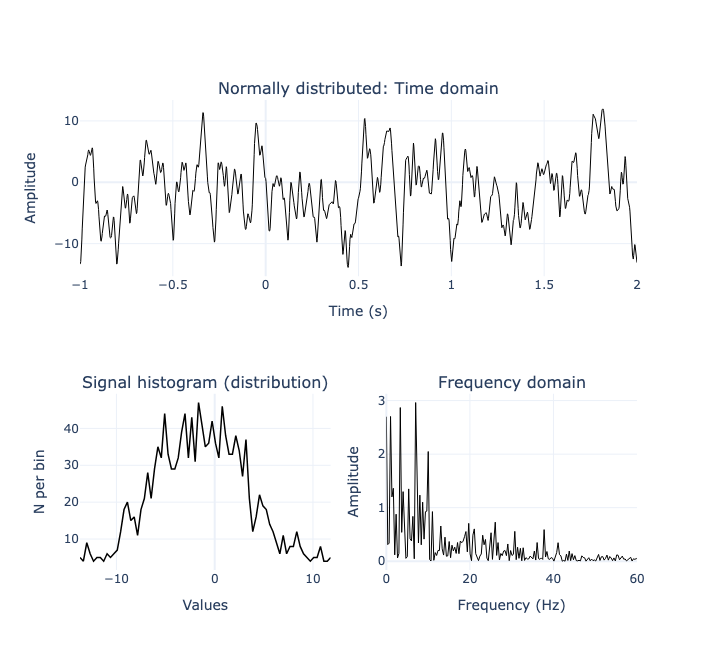

In [34]:
counts, bin_edges = np.histogram(noise, bins=75)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2


fft_vals = np.fft.fft(noise)
amp = np.abs(fft_vals) / pnts
amp = amp[:len(hz)] * 2


fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"colspan": 2}, None],
           [{}, {}]],
    subplot_titles=("Normally distributed: Time domain",
                    "Signal histogram (distribution)",
                    "Frequency domain")
)

fig.add_trace(go.Scatter(x=time, y=noise, mode='lines', line=dict(color='black', width=1)), row=1, col=1)
fig.add_trace(go.Scatter(x=bin_centers, y=counts, mode='lines', line=dict(color='black', width=1.5)), row=2, col=1)
fig.add_trace(go.Scatter(x=hz, y=amp, mode='lines', line=dict(color='black', width=1)), row=2, col=2)

# normally distributed: Time domain
fig.update_xaxes(title_text="Time (s)", row=1, col=1)
fig.update_yaxes(title_text="Amplitude", row=1, col=1)

# signal histogram (distribution)
fig.update_xaxes(title_text="Values", row=2, col=1)
fig.update_yaxes(title_text="N per bin", row=2, col=1)

# frequency domain
fig.update_xaxes(title_text="Frequency (Hz)", range=[0, 60], row=2, col=2)
fig.update_yaxes(title_text="Amplitude", row=2, col=2)

fig.update_layout(showlegend=False, height=650, template="plotly_white")
fig.show()

# Pink Noise (1/f)

In [47]:
srate = 5000 # in hz
step = 1/srate

# np.arange(start, stop_with_buffer, step_size)
time = np.arange(-1, 2 + (step/2), step)

pnts = len(time)

# srate/2 known as the nyquist frequency
# only frequencies half the srate can be measure with certainty
hz = np.linspace(0, srate/2, (pnts//2)-1)


ed = 500 # exponential decay parameter
amp_s_uniform = np.random.rand((pnts // 2) - 1) * np.exp(-np.arange(1, (pnts // 2)) / ed)
amp_s_gaussian = np.random.randn((pnts // 2) - 1) * np.exp(-np.arange(1, (pnts // 2)) / ed)
amp_s = amp_s_uniform

amp_s = np.concatenate(([amp_s[0]], amp_s, [0, 0], amp_s[::-1]))

# regardless of the noise distribution, because we use fft they will both
# follow a normal distribution because of the central limit theorem-
fc = amp_s * np.exp(1j * 2 * np.pi * np.random.rand(len(amp_s)))
noise = np.real(np.fft.ifft(fc)) * pnts

stretch = 1
shift = 0

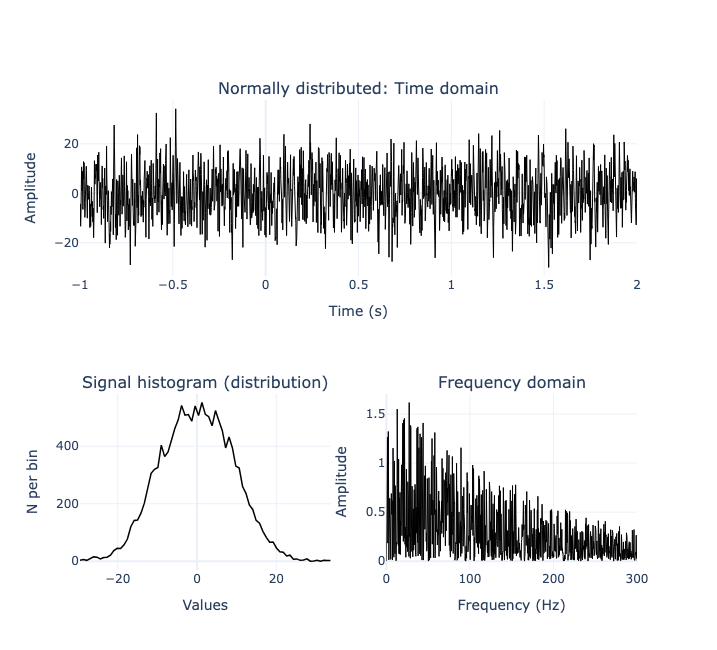

In [46]:
counts, bin_edges = np.histogram(noise, bins=75)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2


fft_vals = np.fft.fft(noise)
amp = np.abs(fft_vals) / pnts
amp = amp[:len(hz)] * 2

fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"colspan": 2}, None],
           [{}, {}]],
    subplot_titles=("Normally distributed: Time domain",
                    "Signal histogram (distribution)",
                    "Frequency domain")
)

fig.add_trace(go.Scatter(x=time, y=noise, mode='lines', line=dict(color='black', width=1)), row=1, col=1)
fig.add_trace(go.Scatter(x=bin_centers, y=counts, mode='lines', line=dict(color='black', width=1.5)), row=2, col=1)
fig.add_trace(go.Scatter(x=hz, y=amp, mode='lines', line=dict(color='black', width=1)), row=2, col=2)

# normally distributed: Time domain
fig.update_xaxes(title_text="Time (s)", row=1, col=1)
fig.update_yaxes(title_text="Amplitude", row=1, col=1)

# signal histogram (distribution)
fig.update_xaxes(title_text="Values", row=2, col=1)
fig.update_yaxes(title_text="N per bin", row=2, col=1)

# frequency domain
fig.update_xaxes(title_text="Frequency (Hz)", range=[0, 300], row=2, col=2)
fig.update_yaxes(title_text="Amplitude", row=2, col=2)

fig.update_layout(showlegend=False, height=650, template="plotly_white")
fig.show()

# Signal (sin)

$$
a * sin(2 \pi f t + \theta)
$$

a = amplitude (1/2 from peak to peak)

f = frequncy

$\theta$ = phase (shift)

# Gaussian

$$
a * e^{-\frac{t^2 - m}{2s^2}}
$$

a = amplitude (peak value)

t = time

m = time point at peak

s = width (full width at half maximum)

OR

$$
e^{\frac{-4 \ln(2) t^2}{h^2}}
$$


t = time

h = FWHM (sec)


# Euler's formula

to describe a vector in polar coordinates

$$
M e^{ik} = M(\cos(k) + i\sin(k))
$$

M = length from origin

k = angle with respect to postive axis

In [64]:
freq = 2 
srate = 1000

step = 1/srate
time = np.arange(-1, 2 + (step/2), step)

amp = 1
phase = np.pi / 3

sin_wave = amp * np.sin(2 *  np.pi * freq * time + phase)

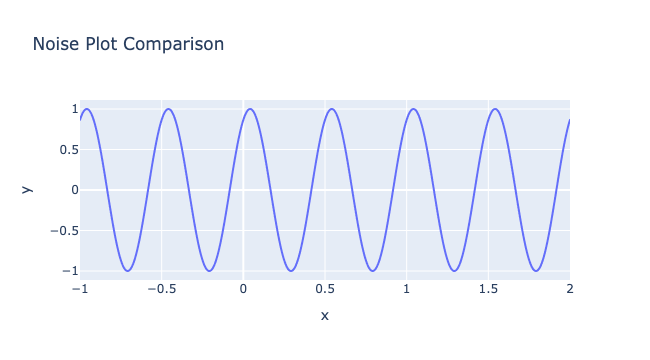

In [65]:
fig = px.line(x=time, y=sin_wave, title="Noise Plot Comparison")
fig.show()

# Simulation of EEG data

In [69]:
freqs = [3, 10, 5, 15, 35]
amps =  [5, 15, 10, 5, 7 ]

phases = [np.pi/7, np.pi/8, np.pi, np.pi/2, -np.pi/4]

sin_waves = []
for i in range(len(freqs)):
    wave = amps[i] * np.sin(2 *  np.pi * freqs[i] * time + phases[i])
    sin_waves.append(wave) 

simulated_eeg = np.sum(sin_waves, axis=0)

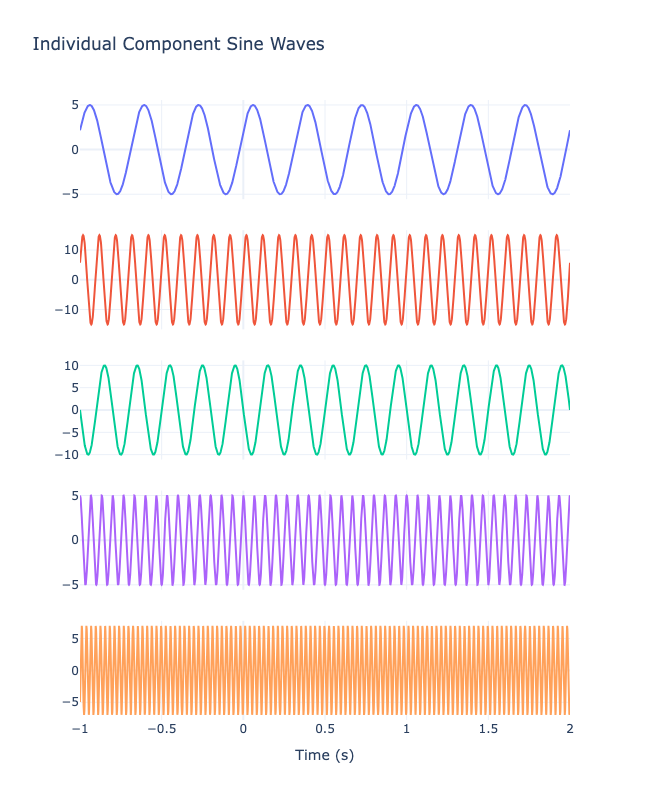

In [76]:
fig = make_subplots(rows=len(freqs), cols=1, shared_xaxes=True, vertical_spacing=0.05)

for i in range(len(freqs)):
    fig.add_trace(
        go.Scatter(x=time, y=sin_waves[i], mode='lines', name=f'{freqs[i]} Hz'),
        row=i+1, col=1
    )

fig.update_layout(
    title="Individual Component Sine Waves",
    height=800, 
    showlegend=False,
    template="plotly_white"
)

fig.update_xaxes(title_text="Time (s)", row=len(freqs), col=1)

fig.show()

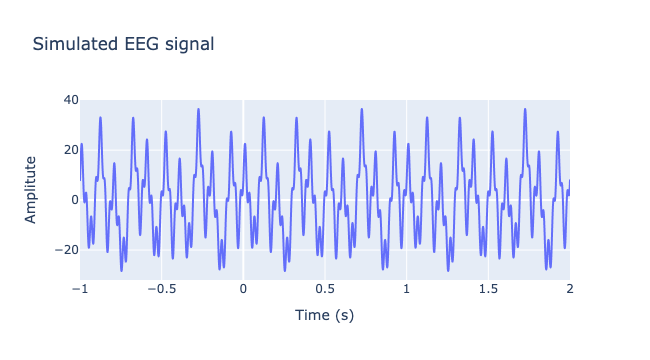

In [74]:
fig = px.line(x=time, y=simulated_eeg, title="Simulated EEG signal")
fig.update_yaxes(title_text="Amplitute")
fig.update_xaxes(title_text="Time (s)")

fig.show()

In [99]:
srate = 1000

step = 1/srate
time = np.arange(-2, 2 + (step/2), step)

peak_time = 1
ampl = 40
fwhm = 0.9

gaussian_window = ampl * np.exp( -4 * np.log(2) * (time - peak_time)**2 / fwhm**2)

gaussian_window_norm = gaussian_window / np.max(gaussian_window)
mid = np.argmin(np.abs(time - peak_time))

pst_50 = mid + np.argmin(np.abs(gaussian_window_norm[mid:] - 0.5))
pre_50 = np.argmin(np.abs(gaussian_window_norm[:mid] - 0.5))

empfwhm = time[pst_50] - time[pre_50]


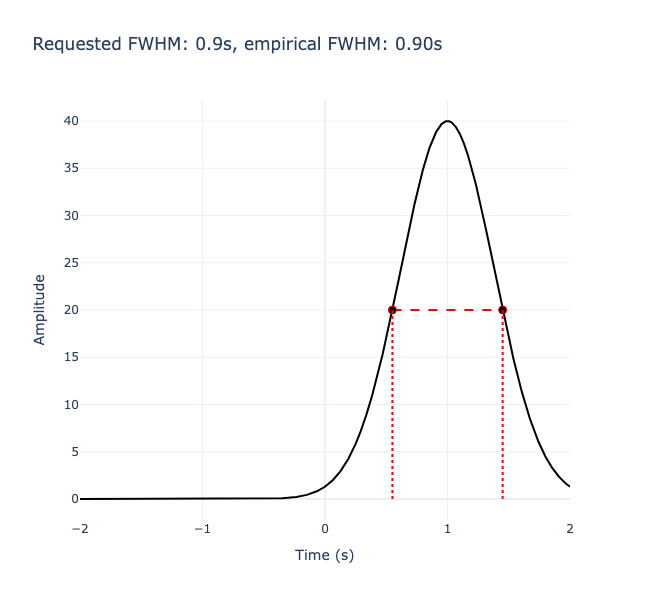

In [102]:
fig = go.Figure()

fig.add_trace(go.Scatter(x=time, y=gaussian_window, mode='lines', line=dict(color='black', width=2)))

fig.add_trace(go.Scatter(
    x=[time[pre_50], time[pst_50]], 
    y=[gaussian_window[pre_50], gaussian_window[pst_50]], 
    mode='lines+markers', 
    line=dict(color='red', dash='dash'), 
    marker=dict(color='black', size=8, line=dict(color='red', width=1))
))

# Liniile verticale roșii punctate care coboară către axa X
fig.add_trace(go.Scatter(x=[time[pre_50], time[pre_50]], y=[0, gaussian_window[pre_50]], mode='lines', line=dict(color='red', dash='dot')))
fig.add_trace(go.Scatter(x=[time[pst_50], time[pst_50]], y=[0, gaussian_window[pst_50]], mode='lines', line=dict(color='red', dash='dot')))

# Formatarea titlului și a axelor pentru a se potrivi cu MATLAB
fig.update_layout(
    title=f"Requested FWHM: {fwhm}s, empirical FWHM: {empfwhm:.2f}s",
    xaxis_title="Time (s)",
    yaxis_title="Amplitude",
    template="plotly_white",
    showlegend=False,
    height=600
)

fig.show()

In [109]:
# Euler's formula
M = 4.4
k = 3 * np.pi / 23
meik = M * np.exp(1j * k)

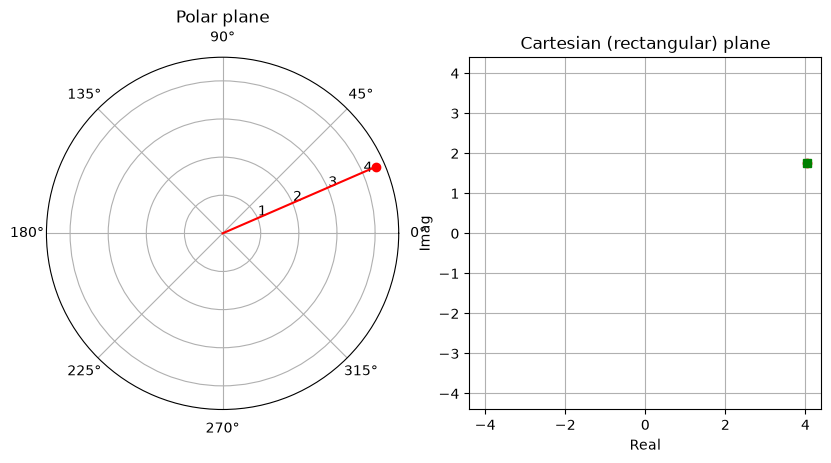

In [110]:
plt.figure(figsize=(10, 5))

# ---- Left: Polar Plane ----
plt.subplot(121, projection='polar') # Matches subplot(121)
plt.plot([0, k], [0, M], 'r')        # Matches polar([0 k], [0 M], 'r')
plt.plot(k, M, 'ro')                 # Matches polar(k, M, 'ro')
plt.title('Polar plane')

# ---- Right: Cartesian Plane ----
plt.subplot(122)                     # Matches subplot(122)
plt.plot(np.real(meik), np.imag(meik), 'ro')
plt.plot(np.real(meik), np.imag(meik), 'gs')

# Format Cartesian (Matches axis square and limits)
limit = np.abs(meik)
plt.axis([-limit, limit, -limit, limit]) 
plt.gca().set_aspect('equal')        # Matches axis square
plt.grid(True)                       # Matches grid on
plt.xlabel('Real')
plt.ylabel('Imag')
plt.title('Cartesian (rectangular) plane')

plt.show()

# Multipolar and frequency-sliding chirp

$$ \sin(2\pi(y_t + t_t)) $$

$y_t$ = instantaneous phase

$t_t$ = time point t from vector t

To calculate the instantaneous phase:

$$ y_t = \delta \sum_{k=1}^t f_k $$

$\delta$ = time step (delta)

$f_k$ = array of interpolated frequencies 

$t$ = current time point index

In [127]:
srate = 1000

step = 1/srate
time = np.arange(-2, 2 + (step/2), step)

freqs = [3, 10, 5, 15, 40, 3, 20, 1]


# f_k vector (smoothly interpolating between your targets)
# distribute the 5 frequency poles evenly across the 4-second time window
pole_times = np.linspace(time[0], time[-1], len(freqs))

f_k = np.interp(time, pole_times, freqs)

y_t = step * np.cumsum(f_k)
chirp = np.sin(2 * np.pi * (y_t + time))



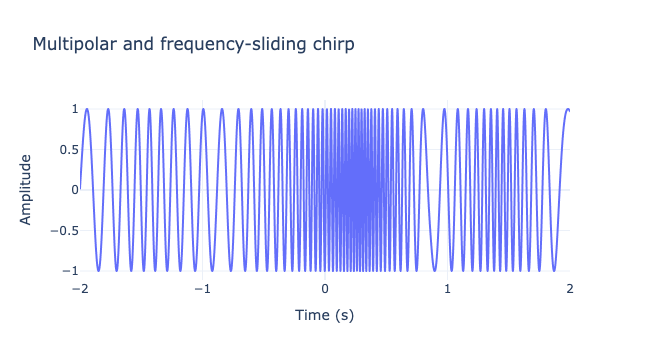

In [128]:
fig = px.line(x=time, y=chirp, title="Multipolar and frequency-sliding chirp")
fig.update_yaxes(title_text="Amplitude")
fig.update_xaxes(title_text="Time (s)")
fig.update_layout(template="plotly_white")

fig.show()

# Transient oscillation

$$ \cos(2\pi f t)e^{-t^2/2s^2} $$

$$ s = \frac{n}{2\pi f} $$

t = time

f = frequency

n = number of cycles

In [152]:

f = 7    # frequency (Hz)
n = 9    # number of cycles
s = n / (2 * np.pi * f)  # width of the Gaussian

time = np.linspace(-1, 3, 150)

t = time - 1 

# The Morlet wavelet formula
wavelet = np.cos(2 * np.pi * f * t) * np.exp(-t**2 / (2 * s**2))

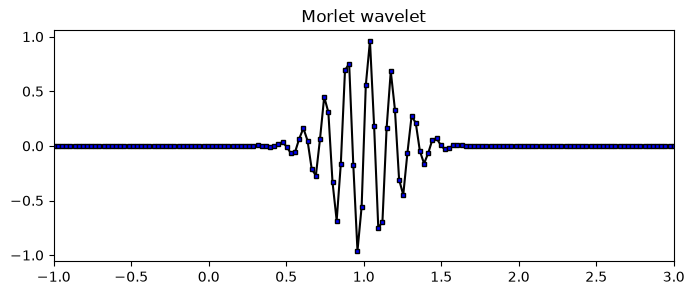

In [151]:
plt.figure(figsize=(8, 3))

plt.plot(time, wavelet, 'k-s', markersize=3, markerfacecolor='b')

plt.title('Morlet wavelet')
plt.xlim([-1, 3])
plt.show()

In [155]:
pnts = 3000 
srate = 1000
time = np.arange(0, pnts) / srate - 1

peaktime = 1  # s
fwhm = 0.4

sinefreq = 7 

gaus = np.exp( -(4 * np.log(2) * (time - peaktime)**2) / fwhm**2 )

# wave with random phase value ("non-phase-locked")
cosw = np.cos(2 * np.pi * sinefreq * time + 2 * np.pi * np.random.rand())

signal = cosw * gaus

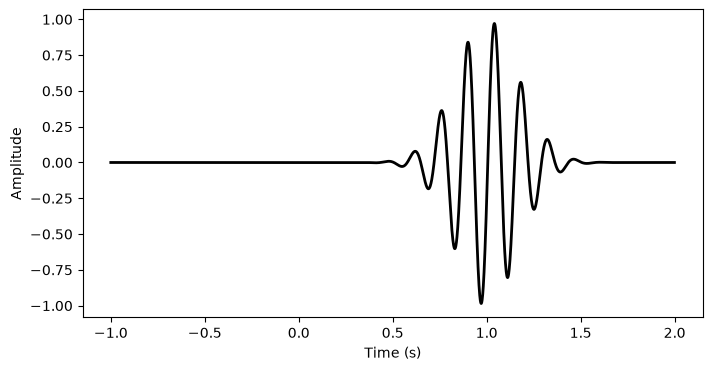

In [156]:
plt.figure(figsize=(8, 4))
plt.plot(time, signal, 'k', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()